In [1]:
# ============================================================================
# CELL 1: CONFIGURATION — Edit this cell for each run
# ============================================================================

# MODEL="gemma-12b"
MODEL="llama-3b"
DATASET="triviaqa"
# DATASET="hotpotqa"

# Main results file
RESULTS_CSV = f"adapters_results/{DATASET}/threshold_0.8/{MODEL}.csv"

# External benchmark files
BIGBENCH_CSV = f"adapters_results/{DATASET}/bigbench_summary.csv"
MMLU_CSV = f"adapters_results/{DATASET}/mmlu_summary.csv"

# Filtering
ACCURACY_THRESHOLD = 0.95        # Minimum accuracy for "qualified" configs
MIN_NEGATIVE_SHIFT = 0          # negative_shift_score > this value

# Size categorization thresholds
LORA_RANK_BINS = {1: 'Small', 3: 'Medium', 8: 'Medium', 16: 'Medium', 32: 'Large'}   # default -> 'Large'
UI_SVECS_BINS = [(0, 32, 'Small'), (64, 256, 'Medium'), (512, float('inf'), 'Large')]
VERA_DEFAULT_SIZE = 'Small'

# Plot settings
FIGURE_SIZE = (15, 10)
TYPE_COLORS = {'lora': '#1f77b4', 'uiortholora': '#2ca02c', 'vera': '#ff7f0e', 'dora': '#9467bd'}
BG_COLORS = {'Small': '#f0f8ff', 'Medium': '#f5f5f5', 'Large': '#fff0f5'}

# Plot title prefix (e.g. model name)
PLOT_TITLE_PREFIX = f"{MODEL} ({DATASET})"

In [ ]:
# ============================================================================
# CELL 2: IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import re

: 

: 

In [ ]:
# ============================================================================
# CELL 3: HELPER FUNCTIONS
# ============================================================================

def load_and_clean(path, accuracy_thresh, min_neg_shift):
    """Load main results CSV and apply basic cleaning/filtering."""
    df = pd.read_csv(path)
    for col in ["lr", "rank", "accuracy", "negative_shift_score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[(df['accuracy'].notna()) & (df['negative_shift_score'] > min_neg_shift)].copy()
    return df


def extract_config_details(row):
    """Parse adapter name into a human-readable label, rank, and svecs."""
    name = row['raw_adapter_name']
    adapter_type = row['adapter_type']

    if adapter_type == 'lora':
        match = re.search(r'lora_r(\d+)', name)
        rank = int(match.group(1)) if match else 0
        return f"LoRA r={rank}", rank, None
    elif adapter_type == 'uiortholora':
        # 1. Check for the newer format (e.g., sv1024_svec128)
        match_new = re.search(r'sv(\d+)_svec(\d+)', name)
        if match_new:
            svec_val = int(match_new.group(2))
            return f"UI-OrthoLoRA svec={svec_val}", None, svec_val
            
        # 2. Check for the older format (e.g., s1024_v32)
        match_old = re.search(r's(\d+)_v(\d+)', name)
        if match_old:
            v_val = int(match_old.group(2))
            return f"UI-OrthoLoRA v={v_val}", None, v_val
            
        # 3. Fallback if neither matches
        return "UI-LoRA", None, None
    elif adapter_type == 'vera':
        match = re.search(r'vera_r(\d+)', name)
        rank = int(match.group(1)) if match else 0
        return f"VeRA r={rank}", rank, None
    elif adapter_type == 'dora':
        match = re.search(r'lora_r(\d+)', name)
        rank = int(match.group(1)) if match else 0
        return f"DoRA r={rank}", rank, None
    return "Unknown", 0, None


def categorize_size(row, lora_bins, ui_bins, vera_default):
    """Assign a size category (Small/Medium/Large) based on adapter type and params."""
    adapter_type = row['adapter_type']
    svecs = row['svecs']
    rank = row['rank_val']

    if adapter_type == 'lora':
        return lora_bins.get(rank, 'Large')
    elif adapter_type == 'uiortholora':
        if svecs is not None:
            for low, high, label in ui_bins:
                if low <= svecs <= high:
                    return label
    elif adapter_type == 'vera':
        return vera_default
    return 'Medium'


def get_best_configs(df, accuracy_thresh):
    """Filter to qualified configs and pick the best (lowest neg shift) per config."""
    qualified = df[df['accuracy'] >= accuracy_thresh].copy()
    # best = qualified.loc[
    #     qualified.groupby('config_label')['negative_shift_score'].idxmin()
    # ].copy()
    # return best
    return qualified


def attach_external_benchmarks(df, bigbench_path, mmlu_path):
    """Map BigBench and MMLU scores onto the best-config dataframe."""
    df_bb = pd.read_csv(bigbench_path)
    df_mm = pd.read_csv(mmlu_path)

    # Split by '/' and take the last part to get the pure adapter name
    df_bb['match_key'] = df_bb['model_path'].str.split('/').str[-1]
    df_mm['match_key'] = df_mm['model_name'].str.split('/').str[-1]

    bb_lookup = df_bb.set_index('match_key')['mean_accuracy'].to_dict()
    mm_lookup = df_mm.set_index('match_key')['mmlu_acc'].to_dict()

    # Ensure we are also comparing against just the pure adapter name in the main df
    df['match_key'] = df['raw_adapter_name'].str.split('/').str[-1]
    
    df['bigbench_acc'] = df['match_key'].map(bb_lookup)
    df['mmlu_acc'] = df['match_key'].map(mm_lookup)
    
    return df

: 

: 

In [ ]:
# ============================================================================
# CELL 4: PROCESS DATA
# ============================================================================

df = load_and_clean(RESULTS_CSV, ACCURACY_THRESHOLD, MIN_NEGATIVE_SHIFT)

df[['config_label', 'rank_val', 'svecs']] = df.apply(
    lambda row: pd.Series(extract_config_details(row)), axis=1
)

df['size_category'] = df.apply(
    categorize_size, axis=1,
    lora_bins=LORA_RANK_BINS, ui_bins=UI_SVECS_BINS, vera_default=VERA_DEFAULT_SIZE
)

best_per_config = get_best_configs(df, ACCURACY_THRESHOLD)
best_per_config = attach_external_benchmarks(best_per_config, BIGBENCH_CSV, MMLU_CSV)

print(f"Total rows after filtering: {len(df)}")
print(f"Qualified configs (acc >= {ACCURACY_THRESHOLD}): {len(best_per_config)}")
best_per_config[['config_label', 'size_category', 'accuracy', 'negative_shift_score', 'bigbench_acc', 'mmlu_acc']]

Total rows after filtering: 104
Qualified configs (acc >= 0.95): 40


,config_label,size_category,accuracy,negative_shift_score,bigbench_acc,mmlu_acc
5,DoRA r=16,Medium,0.998055,24324.9,0.353122,0.239709
7,DoRA r=32,Medium,0.998527,24860.2,0.341879,0.241632
8,DoRA r=3,Medium,0.990920,20272.0,0.342020,0.228386
9,DoRA r=8,Medium,0.997384,23107.3,0.340450,0.232161
10,DoRA r=16,Medium,0.966618,8702.0,0.460304,0.603831
12,DoRA r=32,Medium,0.968023,8556.5,0.467139,0.602549
14,DoRA r=8,Medium,0.963273,8908.7,0.468113,0.600769
25,DoRA r=16,Medium,0.997415,14514.4,0.408339,0.482481
26,DoRA r=1,Medium,0.951977,13910.8,0.388276,0.321607
27,DoRA r=32,Medium,0.997515,14288.8,0.452848,0.489603


: 

: 

In [ ]:
# ============================================================================
# CELL 5: PLOTTING FUNCTIONS
# ============================================================================

def prepare_plot_df(best_df, type_colors):
    """Sort by size then score and assign colors."""
    size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
    best_df = best_df.copy()
    best_df['size_rank'] = best_df['size_category'].map(size_order)
    best_df = best_df.sort_values(by=['size_rank', 'negative_shift_score'], ascending=[True, False])
    best_df['color'] = best_df['adapter_type'].map(type_colors).fillna('grey')
    return best_df


def draw_size_backgrounds(ax, df, bg_colors):
    """Draw colored background bands for each size category."""
    sizes = df['size_category'].values
    current_size = sizes[0]
    start_idx = 0
    for i, size in enumerate(sizes):
        if size != current_size:
            ax.axhspan(start_idx - 0.5, i - 0.5,
                       color=bg_colors.get(current_size, 'white'), alpha=0.5, lw=0, zorder=0)
            current_size = size
            start_idx = i
    ax.axhspan(start_idx - 0.5, len(df) - 0.5,
               color=bg_colors.get(current_size, 'white'), alpha=0.5, lw=0, zorder=0)


def plot_panel(ax, plot_df, metric, title, xlabel, decimals, bg_colors):
    """Draw a single scatter panel."""
    y_range = range(len(plot_df))
    ax.scatter(plot_df[metric], y_range, color=plot_df['color'],
               s=120, edgecolors='black', zorder=3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    draw_size_backgrounds(ax, plot_df, bg_colors)

    # Auto-scale for non-negative-shift metrics
    if metric != 'negative_shift_score':
        vals = plot_df[metric].dropna()
        if not vals.empty:
            padding = (vals.max() - vals.min()) * 0.4
            ax.set_xlim(vals.min() - (padding * 0.2), vals.max() + padding)

    # Text labels
    fmt = f" {{:.{decimals}f}}"
    for i, val in enumerate(plot_df[metric]):
        if pd.notna(val):
            ax.text(val, i, fmt.format(val),
                    va='center', ha='left', fontsize=8, color='#333', fontweight='bold')


def plot_results(plot_df, type_colors, bg_colors, title_prefix, figsize):
    """Create the full 3-panel figure."""
    size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    panels = [
        ('negative_shift_score', 'Negative Shift Score\n(Lower is Better)', 'Score', 1),
        ('bigbench_acc',         'BigBench\n(Higher is Better)',            'Accuracy', 3),
        ('mmlu_acc',             'MMLU\n(Higher is Better)',                'Accuracy', 3),
    ]

    for ax, (metric, title, xlabel, decimals) in zip(axes, panels):
        plot_panel(ax, plot_df, metric, title, xlabel, decimals, bg_colors)

    # Y-axis labels
    labels = plot_df['config_label'].values
    axes[0].set_yticks(range(len(plot_df)))
    axes[0].set_yticklabels(labels, fontsize=11)

    # Size category side labels
    for size_cat in size_order:
        idxs = [i for i, row in enumerate(plot_df.itertuples()) if row.size_category == size_cat]
        if idxs:
            axes[0].text(-0.45, np.mean(idxs), size_cat.upper(),
                         transform=axes[0].get_yaxis_transform(),
                         rotation=90, va='center', ha='center',
                         fontweight='bold', fontsize=12, color='#555')

    # Legend
    legend_handles = [
        mlines.Line2D([], [], color='w', marker='o', markerfacecolor=c,
                       markersize=11, markeredgecolor='k', label=l)
        for l, c in type_colors.items()
    ]
    fig.legend(handles=legend_handles, loc='upper center',
               bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=11, frameon=False)

    fig.suptitle(title_prefix, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(left=0.15, top=0.9, right=0.95)
    plt.show()
    return fig

: 

: 

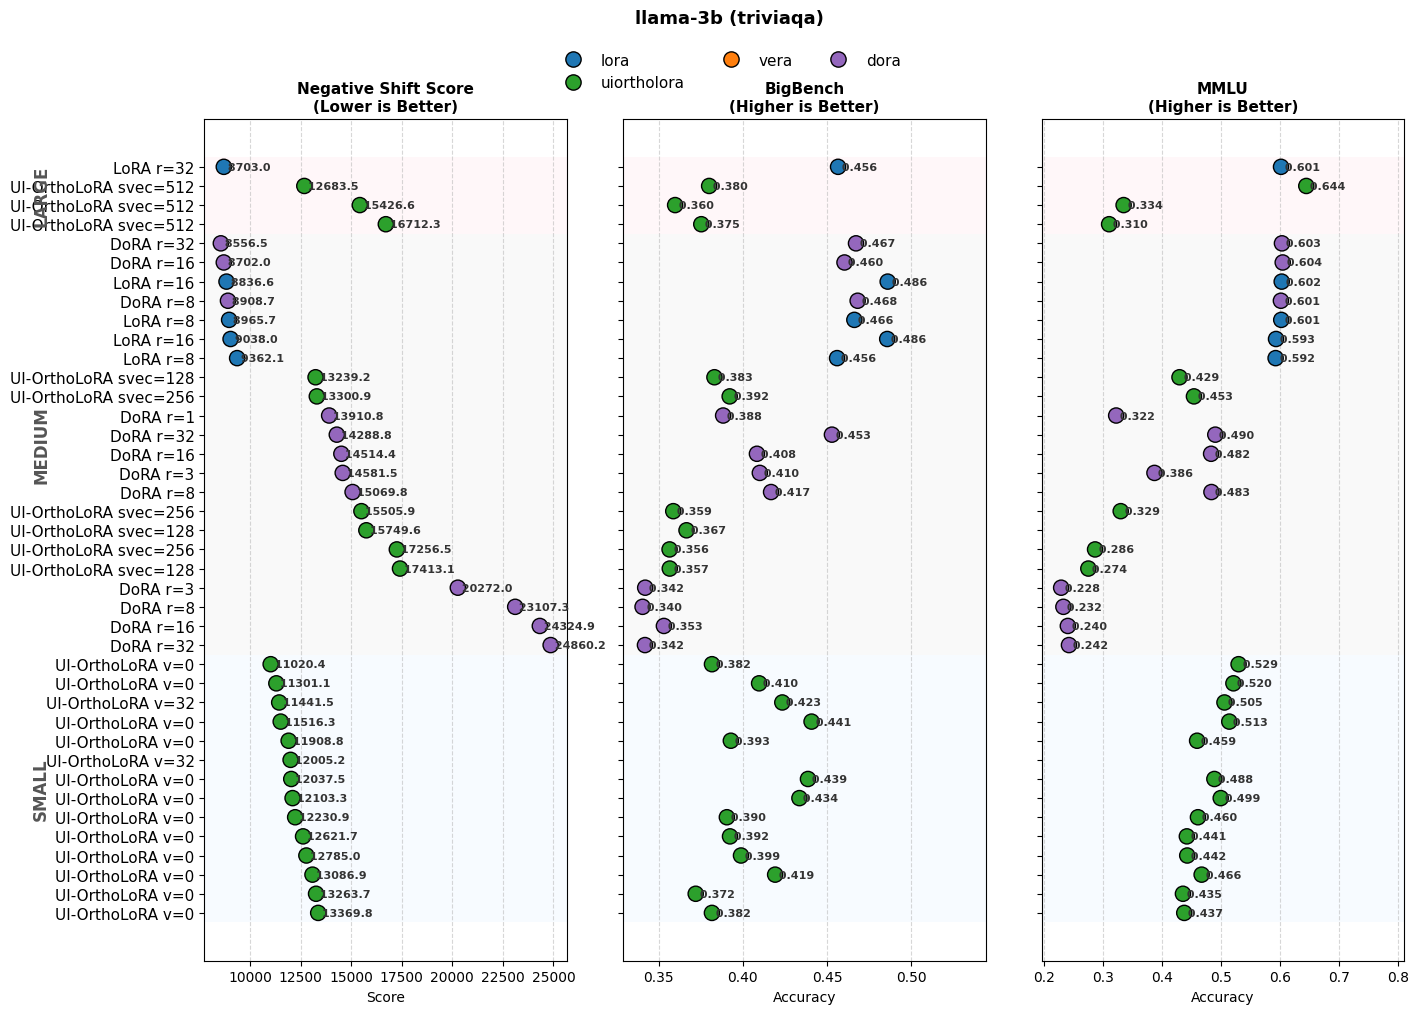

: 

: 

In [ ]:
# ============================================================================
# CELL 6: GENERATE PLOT
# ============================================================================

plot_df = prepare_plot_df(best_per_config, TYPE_COLORS)
fig = plot_results(plot_df, TYPE_COLORS, BG_COLORS, PLOT_TITLE_PREFIX, FIGURE_SIZE)

In [ ]:
best_per_config

,source_file,adapter_type,lr,rank,svals,svecs,tr_from_name,tr_actual,accuracy,negative_shift_count,negative_shift_score,positive_shift_count,positive_shift_score,raw_adapter_name,config_label,rank_val,size_category,match_key,bigbench_acc,mmlu_acc
5,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00100,16,NaN,NaN,NaN,32799,0.998055,24471,24324.9,251,225.9,dora_trAll_lora_r16_lr1e-3,DoRA r=16,16.0,Medium,dora_trAll_lora_r16_lr1e-3,0.353122,0.239709
7,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00100,32,NaN,NaN,NaN,32799,0.998527,25001,24860.2,275,247.5,dora_trAll_lora_r32_lr1e-3,DoRA r=32,32.0,Medium,dora_trAll_lora_r32_lr1e-3,0.341879,0.241632
8,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00100,3,NaN,NaN,NaN,32799,0.990920,20420,20272.0,272,244.8,dora_trAll_lora_r3_lr1e-3,DoRA r=3,3.0,Medium,dora_trAll_lora_r3_lr1e-3,0.342020,0.228386
9,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00100,8,NaN,NaN,NaN,32799,0.997384,23253,23107.3,258,232.2,dora_trAll_lora_r8_lr1e-3,DoRA r=8,8.0,Medium,dora_trAll_lora_r8_lr1e-3,0.340450,0.232161
10,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00010,16,NaN,NaN,NaN,32799,0.966618,8799,8702.0,492,442.8,dora_trAll_lora_r16_lr1e-4,DoRA r=16,16.0,Medium,dora_trAll_lora_r16_lr1e-4,0.460304,0.603831
12,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00010,32,NaN,NaN,NaN,32799,0.968023,8653,8556.5,506,455.4,dora_trAll_lora_r32_lr1e-4,DoRA r=32,32.0,Medium,dora_trAll_lora_r32_lr1e-4,0.467139,0.602549
14,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00010,8,NaN,NaN,NaN,32799,0.963273,9006,8908.7,485,436.5,dora_trAll_lora_r8_lr1e-4,DoRA r=8,8.0,Medium,dora_trAll_lora_r8_lr1e-4,0.468113,0.600769
25,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00050,16,NaN,NaN,NaN,32799,0.997415,14632,14514.4,402,361.8,dora_trAll_lora_r16_lr5e-4,DoRA r=16,16.0,Medium,dora_trAll_lora_r16_lr5e-4,0.408339,0.482481
26,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00050,1,NaN,NaN,NaN,32799,0.951977,14044,13910.8,349,314.1,dora_trAll_lora_r1_lr5e-4,DoRA r=1,1.0,Medium,dora_trAll_lora_r1_lr5e-4,0.388276,0.321607
27,meta-llama_Llama-3.2-3B-Instruct_scores-dora.j...,dora,0.00050,32,NaN,NaN,NaN,32799,0.997515,14408,14288.8,424,381.6,dora_trAll_lora_r32_lr5e-4,DoRA r=32,32.0,Medium,dora_trAll_lora_r32_lr5e-4,0.452848,0.489603


: 

: 

In [ ]:
# Load the CSV
# df = pd.read_csv(RESULTS_CSV)  # change filename as needed
df = best_per_config

# Filter by accuracy threshold
ACC_THRESHOLD = ACCURACY_THRESHOLD
SIZE_CATEGORY = "large"  # "small", "medium", "large", or None for no filter

def filter_by_size(df, size):
    if size is None:
        return df
    
    masks = []
    
    if size == "small":
        # All VeRAs
        masks.append(df['adapter_type'] == 'vera')
        # LoRA/DoRA rank <= 1
        masks.append((df['adapter_type'].isin(['lora', 'dora'])) & (df['rank'] <= 1))
        # OrthoLoRA svecs <= 32
        masks.append((df['adapter_type'] == 'uiortholora') & (df['svecs'] <= 32))
    
    elif size == "medium":
        # No VeRA
        # LoRA/DoRA rank 3-8
        masks.append((df['adapter_type'].isin(['lora', 'dora'])) & (df['rank'] >= 3) & (df['rank'] <= 8))
        # OrthoLoRA svecs <= 256
        masks.append((df['adapter_type'] == 'uiortholora') & (df['svecs'] <= 256))
    
    elif size == "large":
        # No VeRA
        # LoRA/DoRA rank 16-32
        masks.append((df['adapter_type'].isin(['lora', 'dora'])) & (df['rank'] >= 16) & (df['rank'] <= 32))
        # OrthoLoRA svecs == 512
        masks.append((df['adapter_type'] == 'uiortholora') & (df['svecs'] == 512))
    
    combined = masks[0]
    for m in masks[1:]:
        combined = combined | m
    return df[combined]

# Apply filters
filtered = df[df['accuracy'] >= ACC_THRESHOLD].copy()
filtered = filter_by_size(filtered, SIZE_CATEGORY)

# Sort
filtered = filtered.sort_values(
    by=['adapter_type', 'negative_shift_score', 'accuracy'],
    ascending=[True, True, False]
)

cols = ['adapter_type', 'lr', 'rank', 'svals', 'svecs', 'accuracy',
        'negative_shift_score', 'mmlu_acc', 'bigbench_acc']

print(f"Size: {SIZE_CATEGORY or 'all'} | Accuracy >= {ACC_THRESHOLD} | Rows: {len(filtered)}")
print(filtered[cols].to_string(index=False))

Size: small | Accuracy >= 0.95 | Rows: 15
adapter_type     lr  rank  svals  svecs  accuracy  negative_shift_score  mmlu_acc  bigbench_acc
        dora 0.0005     1    NaN    NaN  0.951977               13910.8  0.321607      0.388276
 uiortholora 0.0070  1024 1024.0    0.0  0.958291               11020.4  0.529056      0.381653
 uiortholora 0.0070   256  256.0    0.0  0.956877               11301.1  0.520296      0.409624
 uiortholora 0.0070   256  256.0   32.0  0.956468               11441.5  0.505127      0.423394
 uiortholora 0.0070   512  512.0    0.0  0.954919               11516.3  0.513317      0.440758
 uiortholora 0.0080  1024 1024.0    0.0  0.961532               11908.8  0.458767      0.392851
 uiortholora 0.0080   256  256.0   32.0  0.960822               12005.2       NaN           NaN
 uiortholora 0.0080   256  256.0    0.0  0.963279               12037.5  0.488036      0.438632
 uiortholora 0.0080   512  512.0    0.0  0.963468               12103.3  0.498789      0.43355

: 

: 

: 

: 